# Laboratorium 8 - Architektura enkoder-dekoder, segmentacja obrazu

Ten notebook implementuje:

- **Zadanie 1** - sparowane transformacje (obraz + etykieta) z augmentacją
- **Zadanie 2** - `SimpleEncoderDecoder` ze skip-connections
- **Zadanie 3** - pętla treningowa + walidacyjna z metrykami (loss, accuracy, IoU)
- **Zadanie 4** - parametryzowalny `EncoderDecoder` (wybór głębokości i rodzaju upsamplingu)

Eksperymenty końcowe porównują:

1. `SimpleEncoderDecoder` bez skip-connections vs ze skip-connections
2. `EncoderDecoder` z `ConvTranspose2d` vs `nn.Upsample`
3. Wpływ głębokości sieci na jakość segmentacji

Wszystkie modele są trenowane na zbiorze VOCSegmentation w trybie tło/obiekt (2 klasy).

## Setup - importy i konfiguracja

In [1]:
import os
import time
import random
from typing import List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import PIL
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Reprodukowalność
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce GTX 1050


## Upsampling w sieciach konwolucyjnych

W architekturze enkoder-dekoder mamy dwie ścieżki:

- **enkoder** zmniejsza rozdzielczość przy jednoczesnym zwiększaniu liczby kanałów (więcej semantyki, mniej geometrii)
- **dekoder** zwiększa rozdzielczość z powrotem do oryginalnej, redukując kanały do liczby klas

Na zwiększenie rozdzielczości mamy dwie podstawowe opcje:

- `nn.Upsample` - bezparametrowa interpolacja (nearest/bilinear) - tania, ale nie uczy się
- `nn.ConvTranspose2d` - "konwolucja transponowana", ucząca się odwrotność konwolucji ze stride > 1

In [2]:
# Demonstracja: oba sposoby upsamplingu
upsampler = nn.Upsample(scale_factor=2)
dummy = torch.zeros((3, 3, 32, 32))
print(f"nn.Upsample:        {tuple(dummy.shape)} -> {tuple(upsampler(dummy).shape)}")

deconv = nn.ConvTranspose2d(3, 3, kernel_size=2, stride=2)
print(f"nn.ConvTranspose2d: {tuple(dummy.shape)} -> {tuple(deconv(dummy).shape)}")

# Konwolucja transponowana jako "odwrotność" konwolucji ze stride
conv = nn.Conv2d(3, 3, 3, stride=2, padding=1)
deconv_match = nn.ConvTranspose2d(3, 3, 3, stride=2, padding=1, output_padding=1)
out = deconv_match(conv(dummy))
print(f"Conv->ConvT (output_padding=1): {tuple(dummy.shape)} -> {tuple(conv(dummy).shape)} -> {tuple(out.shape)}")


nn.Upsample:        (3, 3, 32, 32) -> (3, 3, 64, 64)
nn.ConvTranspose2d: (3, 3, 32, 32) -> (3, 3, 64, 64)
Conv->ConvT (output_padding=1): (3, 3, 32, 32) -> (3, 3, 16, 16) -> (3, 3, 32, 32)


## Zadanie 1 - Sparowane transformacje

Etykieta segmentacji to obraz z numerem klasy w każdym pikselu. Augmentacje muszą działać identycznie na obrazie i etykiecie - inaczej rozjedziemy targety.

Wymagania:

- losowa augmentacja (np. flip + crop) w treningowej wersji, brak augmentacji w testowej
- padding do stałego rozmiaru: obraz padowany zerami, etykieta padowana wartością `255` (ignore_index)
- konwersja do tensora: float `[0,1]` dla obrazu, int64 dla etykiety
- przedefiniowanie problemu z 21-klasowego na 2-klasowy: tło (0) vs obiekt (1), zachowując 255 jako ignore

In [3]:
TARGET_SIZE = 128  # po resize //4 typowy obraz VOC ma ~125x100; padujemy lub crop'ujemy do 128x128

def _to_long_tensor(pic: PIL.Image.Image) -> torch.Tensor:
    """Konwersja PIL -> LongTensor bez zmiany wartości pikseli (zachowuje 255)."""
    return torch.as_tensor(np.array(pic, dtype=np.int64), dtype=torch.long)


def _pad_or_crop_to(image: PIL.Image.Image, target: PIL.Image.Image, size: int):
    """Padding lub center-crop do kwadratu size x size.
    Padding: obraz zerami, target 255 (ignore).
    Crop: jeśli obraz jest większy niż size, robimy center-crop."""
    w, h = image.size
    # padding (jeśli mniejsze niż size)
    pad_w = max(0, size - w)
    pad_h = max(0, size - h)
    if pad_w > 0 or pad_h > 0:
        padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
        image = TF.pad(image, padding, fill=0)
        target = TF.pad(target, padding, fill=255)
    # center-crop (jeśli któryś wymiar jest większy niż size)
    w, h = image.size
    if w > size or h > size:
        image = TF.center_crop(image, [size, size])
        target = TF.center_crop(target, [size, size])
    return image, target


def pair_transforms(image: PIL.Image.Image, target: PIL.Image.Image):
    """Transformacja treningowa - z augmentacją."""
    # zmniejszenie kosztu obliczeniowego (jak w oryginalnym notebooku)
    resize = transforms.Resize(
        (image.size[1] // 4, image.size[0] // 4), PIL.Image.NEAREST
    )
    image = resize(image)
    target = resize(target)

    # augmentacja: losowy poziomy flip wspolnie na obrazie i etykiecie
    if random.random() < 0.5:
        image = TF.hflip(image)
        target = TF.hflip(target)

    # padding do TARGET_SIZE x TARGET_SIZE
    image, target = _pad_or_crop_to(image, target, TARGET_SIZE)

    # konwersja do tensora
    out_image = TF.to_tensor(image)            # float [0,1], (3, H, W)
    out_target = _to_long_tensor(target)       # long, (H, W), zachowuje 255

    # binaryzacja: tło=0, ignore=255, wszystko inne -> obiekt=1
    out_target = torch.where(
        torch.logical_or(out_target == 0, out_target == 255),
        out_target,
        torch.tensor(1, dtype=torch.long),
    )
    return out_image, out_target


def test_pair_transforms(image: PIL.Image.Image, target: PIL.Image.Image):
    """Transformacja walidacyjna - bez augmentacji."""
    resize = transforms.Resize(
        (image.size[1] // 4, image.size[0] // 4), PIL.Image.NEAREST
    )
    image = resize(image)
    target = resize(target)

    image, target = _pad_or_crop_to(image, target, TARGET_SIZE)

    out_image = TF.to_tensor(image)
    out_target = _to_long_tensor(target)
    out_target = torch.where(
        torch.logical_or(out_target == 0, out_target == 255),
        out_target,
        torch.tensor(1, dtype=torch.long),
    )
    return out_image, out_target


### Załadowanie zbioru VOCSegmentation

In [4]:
data = datasets.VOCSegmentation("root", download=True, transforms=pair_transforms)
test_data = datasets.VOCSegmentation(
    "root", download=True, image_set="val", transforms=test_pair_transforms
)
print(f"Treningowych próbek: {len(data)}")
print(f"Walidacyjnych próbek: {len(test_data)}")


100%|██████████| 2.00G/2.00G [03:27<00:00, 9.63MB/s]


Extracting root/VOCtrainval_11-May-2012.tar to root
Using downloaded and verified file: root/VOCtrainval_11-May-2012.tar
Extracting root/VOCtrainval_11-May-2012.tar to root
Treningowych próbek: 1464
Walidacyjnych próbek: 1449


### Weryfikacja transformacji - zgodność obrazu i etykiety

Wyświetlamy kilka próbek treningowych. Etykieta jest pokazana w trzech kolorach: czarny=tło, czerwony=obiekt, szary=`ignore (255)`. Brzegi obiektów powinny być oznaczone jako ignore - to celowe oznaczenie z VOC.

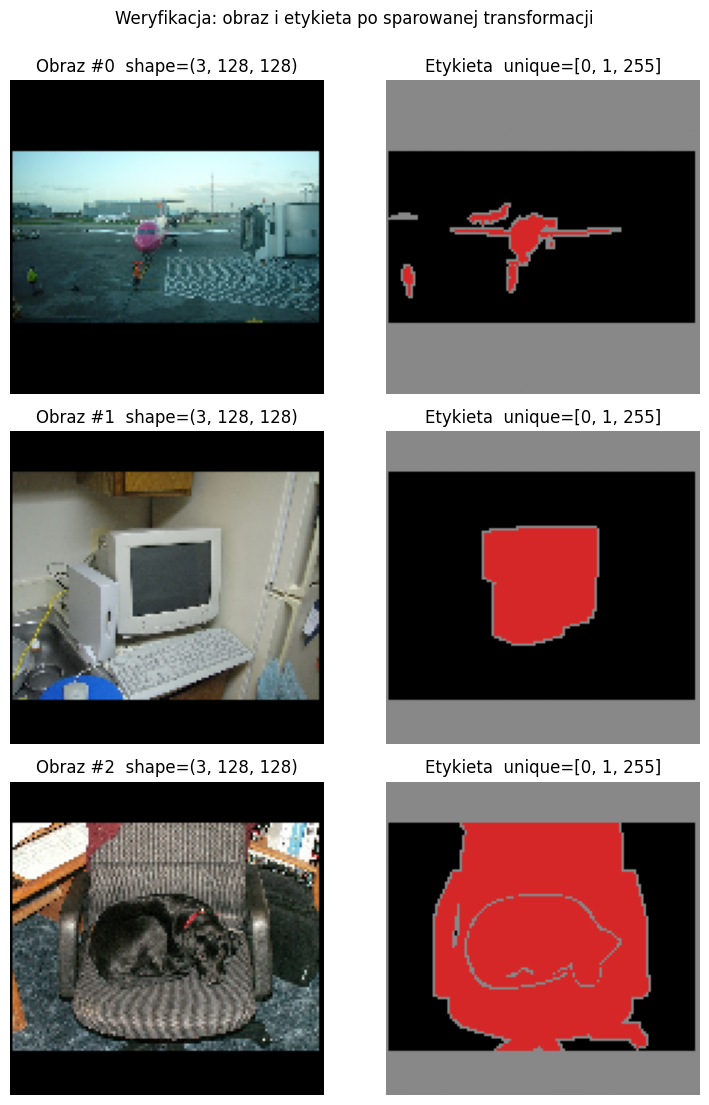

In [5]:
SEG_CMAP = ListedColormap(["#000000", "#d62728", "#888888"])  # 0=bg, 1=obj, 2=ignore

def label_to_display(label: torch.Tensor) -> np.ndarray:
    """Mapuje tensor etykiet (0/1/255) na 0/1/2 do wyświetlenia z SEG_CMAP."""
    arr = label.numpy().copy()
    display = np.zeros_like(arr)
    display[arr == 1] = 1
    display[arr == 255] = 2
    return display


fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for i in range(3):
    img, lbl = data[i]
    axes[i, 0].imshow(img.permute(1, 2, 0))
    axes[i, 0].set_title(f"Obraz #{i}  shape={tuple(img.shape)}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(label_to_display(lbl), cmap=SEG_CMAP, vmin=0, vmax=2)
    axes[i, 1].set_title(f"Etykieta  unique={sorted(set(lbl.unique().tolist()))}")
    axes[i, 1].axis("off")
plt.suptitle("Weryfikacja: obraz i etykieta po sparowanej transformacji", y=1.0)
plt.tight_layout()
plt.show()


## Zadanie 2 - SimpleEncoderDecoder ze skip-connections

Skip-connections (połączenia skrótowe) łączą warstwy enkodera z warstwami dekodera o tej samej rozdzielczości. Bez nich dekoder musiałby zrekonstruować dokładną geometrię obrazu z bardzo skompresowanej reprezentacji - z nimi dostaje "podpowiedzi" z wcześniejszych warstw.

Tutaj realizujemy je przez **dodawanie** (addition), nie konkatenację - dzięki temu liczba kanałów się nie zmienia i nie trzeba modyfikować dalszych warstw.

Schemat:

```
conv_1 -> pool -|----------------------------> + -> up_conv3 -> out
conv_2 -> pool -|----------------> + -> up_conv2
conv_3 -> pool -|--> + -> up_conv1
conv_4 (bottleneck)
```

In [6]:
class SimpleEncoderDecoder(nn.Module):
    """Trzy poziomy down/up + bottleneck. Skip-connections przez DODAWANIE.

    Aby dodawanie zgadzało się w kanałach i rozdzielczości, modyfikujemy strukturę
    względem wersji bez skip:
      - upsamplingi pozostawiają liczbę kanałów taką samą jak skip (c2/c1/c0),
      - dodatkowe konwolucje 1x1 (`align_*`) redukują kanały po dodaniu skipa,
      - ostatnia warstwa konwolucyjna 1x1 produkuje logity (`out_labels` kanałów).
    """

    def __init__(self, channels: List[int], out_labels: int):
        super().__init__()
        c0, c1, c2 = channels[0], channels[1], channels[2]

        # enkoder
        self.conv_1 = nn.Conv2d(3, c0, 3, padding=1)
        self.conv_2 = nn.Conv2d(c0, c1, 3, padding=1)
        self.conv_3 = nn.Conv2d(c1, c2, 3, padding=1)
        # bottleneck
        self.conv_4 = nn.Conv2d(c2, c2, 3, padding=1)
        # dekoder: up_conv zachowuje liczbę kanałów (żeby zgodzić się ze skipem),
        # a align_conv redukuje kanały do potrzebnych w następnym kroku
        self.up_conv1 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.align_1 = nn.Conv2d(c2, c1, 1)
        self.up_conv2 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.align_2 = nn.Conv2d(c1, c0, 1)
        self.up_conv3 = nn.ConvTranspose2d(c0, c0, 2, stride=2)
        self.final_conv = nn.Conv2d(c0, out_labels, 1)

        self.pool = nn.MaxPool2d(2)
        self.act = nn.ReLU()
        self.bnorm = nn.BatchNorm2d(c2)

    def forward(self, x):
        # enkoder - zapamiętujemy aktywacje DO dodania jako skip
        s0 = self.act(self.conv_1(x))      # (B, c0, H,   W)
        x = self.pool(s0)                  # (B, c0, H/2, W/2)
        s1 = self.act(self.conv_2(x))      # (B, c1, H/2, W/2)
        x = self.pool(s1)                  # (B, c1, H/4, W/4)
        s2 = self.act(self.conv_3(x))      # (B, c2, H/4, W/4)
        x = self.pool(s2)                  # (B, c2, H/8, W/8)
        # bottleneck
        x = self.bnorm(x)
        x = self.act(self.conv_4(x))       # (B, c2, H/8, W/8)
        # dekoder + skip-connections (dodawanie)
        x = self.act(self.up_conv1(x))     # (B, c2, H/4, W/4)
        x = x + s2                         # skip: kanały c2, rozdz. H/4 - PASUJE
        x = self.act(self.align_1(x))      # (B, c1, H/4, W/4)
        x = self.act(self.up_conv2(x))     # (B, c1, H/2, W/2)
        x = x + s1                         # skip: kanały c1, rozdz. H/2 - PASUJE
        x = self.act(self.align_2(x))      # (B, c0, H/2, W/2)
        x = self.act(self.up_conv3(x))     # (B, c0, H,   W)
        x = x + s0                         # skip: kanały c0, rozdz. H - PASUJE
        x = self.final_conv(x)             # (B, out_labels, H, W) - logity
        return x


class SimpleEncoderDecoderNoSkip(nn.Module):
    """Wariant bez skip-connections (oryginalny szkielet z notebooka) - do porównania."""

    def __init__(self, channels: List[int], out_labels: int):
        super().__init__()
        self.conv_1 = nn.Conv2d(3, channels[0], 3, padding=1)
        self.conv_2 = nn.Conv2d(channels[0], channels[1], 3, padding=1)
        self.conv_3 = nn.Conv2d(channels[1], channels[2], 3, padding=1)
        self.conv_4 = nn.Conv2d(channels[2], channels[2], 3, padding=1)
        self.up_conv1 = nn.ConvTranspose2d(channels[2], channels[1], 2, stride=2)
        self.up_conv2 = nn.ConvTranspose2d(channels[1], channels[0], 2, stride=2)
        self.up_conv3 = nn.ConvTranspose2d(channels[0], out_labels, 2, stride=2)
        self.pool = nn.MaxPool2d(2)
        self.act = nn.ReLU()
        self.bnorm = nn.BatchNorm2d(channels[2])

    def forward(self, x):
        x = self.pool(self.act(self.conv_1(x)))
        x = self.pool(self.act(self.conv_2(x)))
        x = self.pool(self.act(self.conv_3(x)))
        x = self.bnorm(x)
        x = self.act(self.conv_4(x))
        x = self.act(self.up_conv1(x))
        x = self.act(self.up_conv2(x))
        x = self.up_conv3(x)
        return x


### Weryfikacja zachowania wymiarów

Sieć ma ostatecznie produkować mapę logitów o rozdzielczości równej wejściu i `out_labels` kanałach.

In [7]:
# Test obu wariantów
for cls, name in [(SimpleEncoderDecoder, "ze skip-conn"),
                  (SimpleEncoderDecoderNoSkip, "bez skip-conn")]:
    m = cls([32, 64, 128], 21).to(DEVICE)
    dummy = torch.zeros((4, 3, 64, 64), device=DEVICE)
    out = m(dummy)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name}: input {tuple(dummy.shape)} -> output {tuple(out.shape)}, params={n_params:,}")
    assert out.shape == (4, 21, 64, 64)
print("OK - obydwa modele zwracają poprawny kształt.")


ze skip-conn: input (4, 3, 64, 64) -> output (4, 21, 64, 64), params=338,357
bez skip-conn: input (4, 3, 64, 64) -> output (4, 21, 64, 64), params=284,853
OK - obydwa modele zwracają poprawny kształt.


## Zadanie 3 - Pętle treningowa i walidacyjna

Funkcja kosztu: `CrossEntropyLoss(ignore_index=255)` - automatycznie pomija piksele oznaczone jako "ignore".

Metryki na zbiorze walidacyjnym:

- **loss** - jak wyżej, średni po pikselach
- **accuracy** - frakcja poprawnie sklasyfikowanych pikseli (z pominięciem 255)
- **IoU (Intersection over Union)** - kluczowa metryka segmentacji, odporna na niezbalansowanie klas

Standardowe accuracy w segmentacji bywa zafałszowane: jeśli 80% obrazu to tło, sieć która przewidzi wszystko jako tło dostaje 80% accuracy. IoU patrzy na każdą klasę osobno - liczy `|prediction ∩ ground_truth| / |prediction ∪ ground_truth|`. Raportujemy **mean IoU** uśrednione po klasach (bez tła wliczonego do średniej dla niezbalansowanych zbiorów - tu zostawiamy mIoU po obu klasach dla prostoty, bo problem jest binarny).

In [8]:
@torch.no_grad()
def validate(
    model: nn.Module,
    loss_fn: nn.CrossEntropyLoss,
    dataloader: DataLoader,
) -> Tuple[float, float, float]:
    """Zwraca (avg_loss, pixel_accuracy, mean_IoU)."""
    model.eval()
    num_classes = None  # ustalimy z pierwszego batcha
    loss_sum, loss_count = 0.0, 0
    correct_pixels, total_pixels = 0, 0
    intersection = None
    union = None

    for images, targets in dataloader:
        images = images.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        logits = model(images)               # (B, C, H, W)
        if num_classes is None:
            num_classes = logits.shape[1]
            intersection = torch.zeros(num_classes, device=DEVICE)
            union = torch.zeros(num_classes, device=DEVICE)

        loss = loss_fn(logits, targets)
        # batch_size * H * W * C? -- bierzemy ważone liczbą valid pikseli, ale dla raportu wystarczy mean per batch
        loss_sum += loss.item() * images.size(0)
        loss_count += images.size(0)

        preds = logits.argmax(dim=1)         # (B, H, W)
        valid = targets != 255               # maska: gdzie etykieta jest valid

        # accuracy
        correct_pixels += ((preds == targets) & valid).sum().item()
        total_pixels += valid.sum().item()

        # IoU per klasa
        for c in range(num_classes):
            pred_c = (preds == c) & valid
            target_c = (targets == c) & valid
            intersection[c] += (pred_c & target_c).sum().float()
            union[c] += (pred_c | target_c).sum().float()

    avg_loss = loss_sum / max(loss_count, 1)
    accuracy = correct_pixels / max(total_pixels, 1)
    iou_per_class = intersection / union.clamp(min=1)
    # tylko klasy obecne w zbiorze
    valid_classes = union > 0
    mean_iou = iou_per_class[valid_classes].mean().item() if valid_classes.any() else 0.0

    return avg_loss, accuracy, mean_iou


def fit(
    model: nn.Module,
    optimiser: optim.Optimizer,
    loss_fn: nn.CrossEntropyLoss,
    train_dl: DataLoader,
    val_dl: DataLoader,
    epochs: int,
    print_metrics: bool = True,
) -> dict:
    """Trenuje model. Zwraca historię metryk per epoka."""
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_iou": []}
    t_start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss, epoch_count = 0.0, 0
        for images, targets in train_dl:
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)

            optimiser.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimiser.step()

            epoch_loss += loss.item() * images.size(0)
            epoch_count += images.size(0)

        train_loss = epoch_loss / max(epoch_count, 1)
        val_loss, val_acc, val_iou = validate(model, loss_fn, val_dl)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_iou"].append(val_iou)

        if print_metrics:
            elapsed = time.time() - t_start
            print(
                f"Epoka {epoch:3d}/{epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f} | "
                f"val_mIoU={val_iou:.4f} | "
                f"elapsed={elapsed:.1f}s"
            )
    return history


### Eksperyment 1 - SimpleEncoderDecoder ze skip-connections

VOCSegmentation w wersji binarnej (tło/obiekt) jest wciąż trudny - nie spodziewajmy się rekordowych wyników. Cel: pokazać działanie pętli i porównać warianty architektur.

In [9]:
BATCH_SIZE = 32
EPOCHS = 15  # kompromis czas/jakość; zwiększ do ~50 jeśli masz czas

train_dl = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_dl = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

loss_fn = nn.CrossEntropyLoss(ignore_index=255)

print("=" * 70)
print("Eksperyment 1: SimpleEncoderDecoder ze skip-connections")
print("=" * 70)
torch.manual_seed(SEED)
model_skip = SimpleEncoderDecoder([32, 64, 128], 2).to(DEVICE)
optimizer = optim.Adam(model_skip.parameters())
hist_skip = fit(model_skip, optimizer, loss_fn, train_dl, test_dl, EPOCHS)


Eksperyment 1: SimpleEncoderDecoder ze skip-connections
Epoka   1/15 | train_loss=0.5536 | val_loss=0.5205 | val_acc=0.7329 | val_mIoU=0.3664 | elapsed=17.2s
Epoka   2/15 | train_loss=0.5069 | val_loss=0.5201 | val_acc=0.7333 | val_mIoU=0.3681 | elapsed=26.9s
Epoka   3/15 | train_loss=0.4827 | val_loss=0.4913 | val_acc=0.7506 | val_mIoU=0.5494 | elapsed=33.4s
Epoka   4/15 | train_loss=0.4716 | val_loss=0.4556 | val_acc=0.7752 | val_mIoU=0.5362 | elapsed=42.8s
Epoka   5/15 | train_loss=0.4568 | val_loss=0.4499 | val_acc=0.7792 | val_mIoU=0.5420 | elapsed=49.3s
Epoka   6/15 | train_loss=0.4533 | val_loss=0.4661 | val_acc=0.7638 | val_mIoU=0.4682 | elapsed=55.8s
Epoka   7/15 | train_loss=0.4431 | val_loss=0.4484 | val_acc=0.7812 | val_mIoU=0.5614 | elapsed=62.2s
Epoka   8/15 | train_loss=0.4418 | val_loss=0.4370 | val_acc=0.7851 | val_mIoU=0.5466 | elapsed=69.1s
Epoka   9/15 | train_loss=0.4378 | val_loss=0.4641 | val_acc=0.7700 | val_mIoU=0.4854 | elapsed=79.1s
Epoka  10/15 | train_loss=

### Eksperyment 2 - SimpleEncoderDecoder bez skip-connections (baseline)

In [10]:
print("=" * 70)
print("Eksperyment 2: SimpleEncoderDecoder BEZ skip-connections (baseline)")
print("=" * 70)
torch.manual_seed(SEED)
model_noskip = SimpleEncoderDecoderNoSkip([32, 64, 128], 2).to(DEVICE)
optimizer = optim.Adam(model_noskip.parameters())
hist_noskip = fit(model_noskip, optimizer, loss_fn, train_dl, test_dl, EPOCHS)


Eksperyment 2: SimpleEncoderDecoder BEZ skip-connections (baseline)
Epoka   1/15 | train_loss=0.5329 | val_loss=0.5487 | val_acc=0.7329 | val_mIoU=0.3664 | elapsed=5.0s
Epoka   2/15 | train_loss=0.4854 | val_loss=0.4756 | val_acc=0.7491 | val_mIoU=0.4390 | elapsed=10.0s
Epoka   3/15 | train_loss=0.4688 | val_loss=0.4762 | val_acc=0.7686 | val_mIoU=0.5043 | elapsed=14.9s
Epoka   4/15 | train_loss=0.4676 | val_loss=0.4772 | val_acc=0.7555 | val_mIoU=0.4503 | elapsed=19.7s
Epoka   5/15 | train_loss=0.4515 | val_loss=0.4871 | val_acc=0.7560 | val_mIoU=0.4426 | elapsed=27.5s
Epoka   6/15 | train_loss=0.4520 | val_loss=0.5072 | val_acc=0.7530 | val_mIoU=0.4328 | elapsed=32.3s
Epoka   7/15 | train_loss=0.4410 | val_loss=0.5105 | val_acc=0.7266 | val_mIoU=0.5412 | elapsed=37.2s
Epoka   8/15 | train_loss=0.4415 | val_loss=0.4647 | val_acc=0.7755 | val_mIoU=0.5105 | elapsed=42.0s
Epoka   9/15 | train_loss=0.4374 | val_loss=0.4481 | val_acc=0.7844 | val_mIoU=0.5804 | elapsed=46.7s
Epoka  10/15 | 

### Wykresy: skip vs no-skip

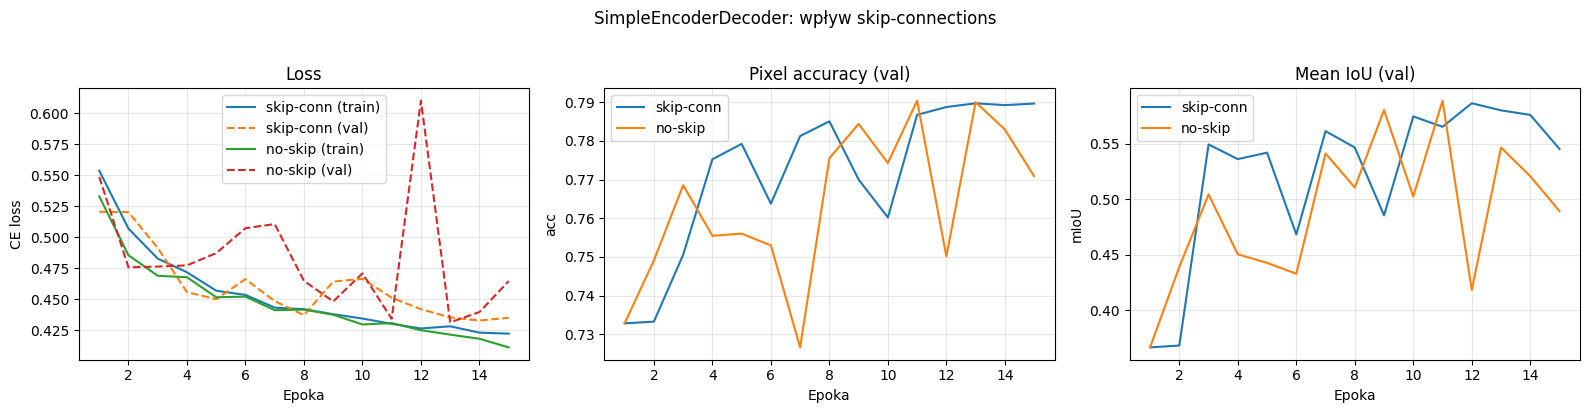

In [11]:
def plot_history(histories: dict, title: str = ""):
    """histories: {label: history_dict}"""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for label, h in histories.items():
        epochs_x = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(epochs_x, h["train_loss"], label=f"{label} (train)")
        axes[0].plot(epochs_x, h["val_loss"], label=f"{label} (val)", linestyle="--")
        axes[1].plot(epochs_x, h["val_acc"], label=label)
        axes[2].plot(epochs_x, h["val_iou"], label=label)

    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoka"); axes[0].set_ylabel("CE loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].set_title("Pixel accuracy (val)")
    axes[1].set_xlabel("Epoka"); axes[1].set_ylabel("acc"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].set_title("Mean IoU (val)")
    axes[2].set_xlabel("Epoka"); axes[2].set_ylabel("mIoU"); axes[2].legend(); axes[2].grid(alpha=0.3)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


plot_history(
    {"skip-conn": hist_skip, "no-skip": hist_noskip},
    title="SimpleEncoderDecoder: wpływ skip-connections",
)


### Wizualne porównanie predykcji

Dla kilku przykładów ze zbioru walidacyjnego porównujemy: obraz wejściowy, ground truth, predykcję modelu ze skip-connections, predykcję bez skip.

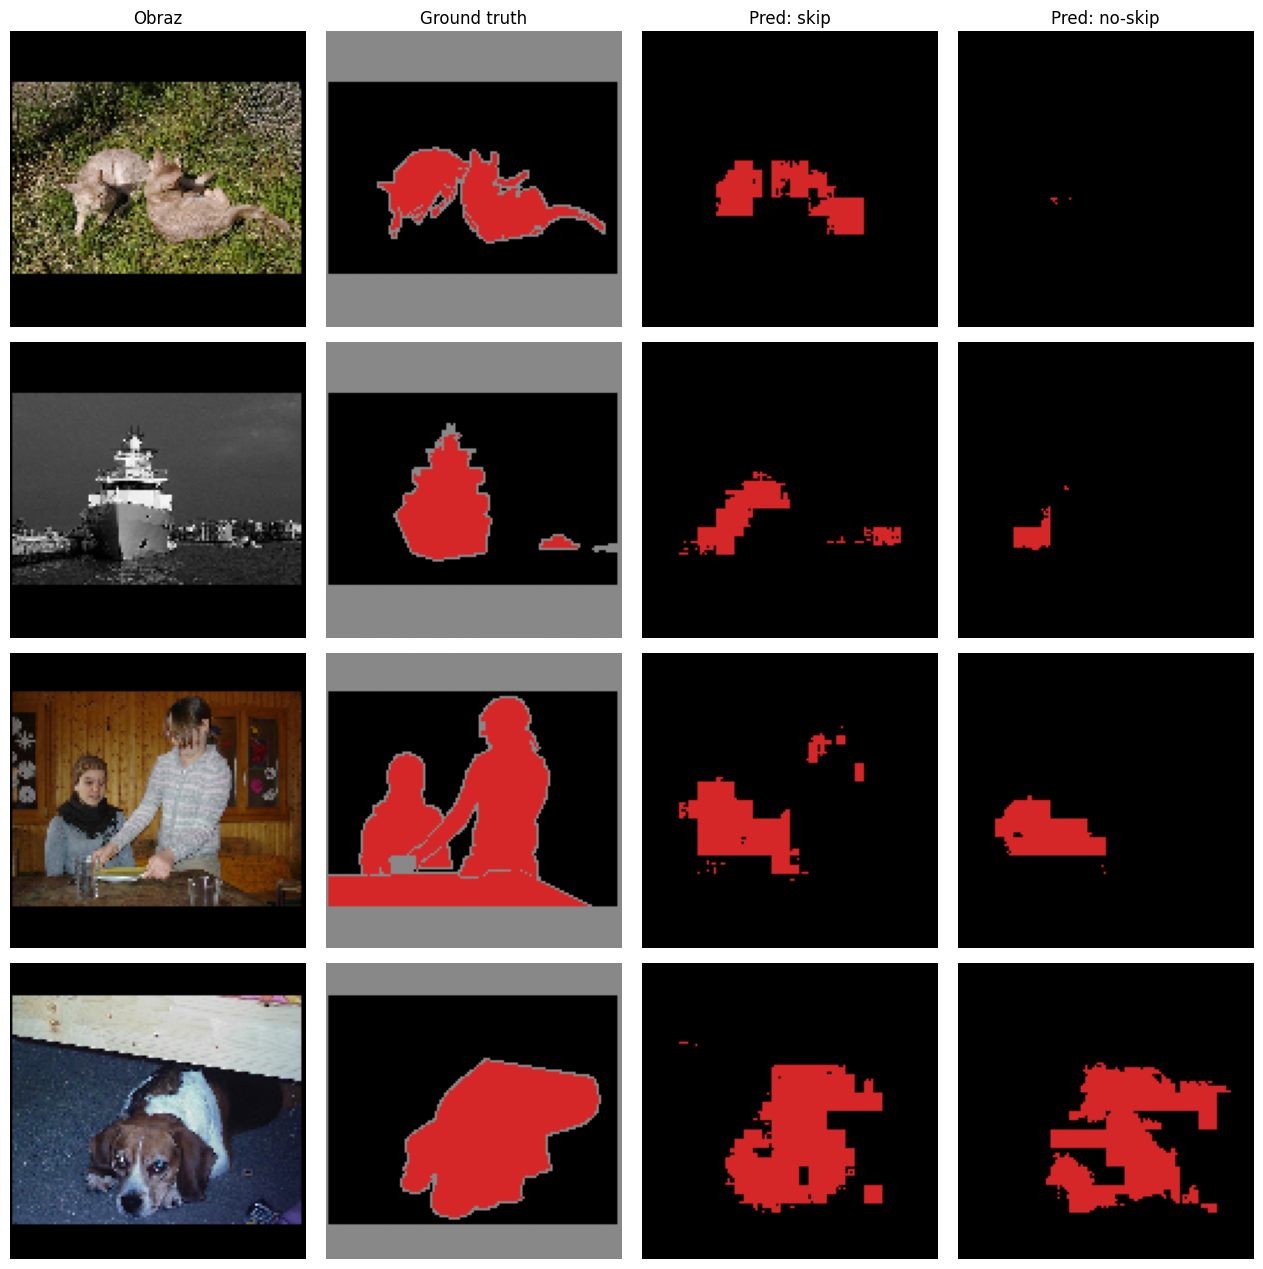

In [12]:
@torch.no_grad()
def predict_one(model: nn.Module, image: torch.Tensor) -> np.ndarray:
    model.eval()
    logits = model(image.unsqueeze(0).to(DEVICE))
    return logits.argmax(dim=1).squeeze(0).cpu().numpy()


def show_predictions(models: dict, dataset, n: int = 4, indices: Optional[List[int]] = None):
    if indices is None:
        rng = np.random.default_rng(SEED)
        indices = rng.choice(len(dataset), size=n, replace=False).tolist()
    n = len(indices)
    n_cols = 2 + len(models)
    fig, axes = plt.subplots(n, n_cols, figsize=(3.2 * n_cols, 3.2 * n))
    if n == 1:
        axes = axes[None, :]
    for row, idx in enumerate(indices):
        img, lbl = dataset[idx]
        axes[row, 0].imshow(img.permute(1, 2, 0)); axes[row, 0].axis("off")
        if row == 0: axes[row, 0].set_title("Obraz")
        axes[row, 1].imshow(label_to_display(lbl), cmap=SEG_CMAP, vmin=0, vmax=2)
        axes[row, 1].axis("off")
        if row == 0: axes[row, 1].set_title("Ground truth")
        for col, (name, mdl) in enumerate(models.items(), start=2):
            pred = predict_one(mdl, img)
            axes[row, col].imshow(pred, cmap=SEG_CMAP, vmin=0, vmax=2)
            axes[row, col].axis("off")
            if row == 0: axes[row, col].set_title(f"Pred: {name}")
    plt.tight_layout()
    plt.show()


show_predictions(
    {"skip": model_skip, "no-skip": model_noskip},
    test_data,
    n=4,
)


## Zadanie 4 - Parametryzowalny EncoderDecoder

Wymagania:

- liczba warstw określana przez długość listy `channels` (nie hardcodowane 3 poziomy)
- skip-connections przez **dodawanie** między warstwami enkodera i dekodera o tej samej rozdzielczości
- wybór upsamplingu: `ConvTranspose2d` (uczący się) lub `nn.Upsample` + `Conv2d` 1x1 (do redukcji kanałów)

Konstrukcja używa `nn.ModuleList`, żeby liczba warstw była dynamiczna. Każdy poziom enkodera składa się z `Conv -> BN -> ReLU`. Dekoder symetrycznie odwraca enkoder; skip dodaje aktywację enkodera o pasującej rozdzielczości po upsamplingu.

In [13]:
class EncoderDecoder(nn.Module):
    """Parametryzowalna sieć enkoder-dekoder ze skip-connections (przez DODAWANIE).

    Args:
        channels: lista liczb kanałów na kolejnych poziomach enkodera, np. [32, 64, 128, 256].
                  Długość listy = liczba poziomów down/up. Dla N=len(channels):
                  enkoder = N bloków + N pooli, dekoder = N upsamplingów ze skip-connections.
        out_labels: liczba klas wyjściowych.
        upsample_mode: "convtranspose" (uczący się) lub "upsample" (interpolacja + 1x1 conv).
        in_channels: liczba kanałów wejściowych (3 dla RGB).
    """

    def __init__(
        self,
        channels: List[int],
        out_labels: int,
        upsample_mode: str = "convtranspose",
        in_channels: int = 3,
    ):
        super().__init__()
        assert upsample_mode in ("convtranspose", "upsample")
        assert len(channels) >= 2, "potrzeba co najmniej 2 poziomów"

        self.channels = list(channels)
        self.upsample_mode = upsample_mode
        N = len(self.channels)

        # ENKODER: N bloków Conv->BN->ReLU. Pool po każdym bloku (też po ostatnim, przed bottleneckiem).
        self.enc_blocks = nn.ModuleList()
        prev_c = in_channels
        for c in self.channels:
            self.enc_blocks.append(
                nn.Sequential(
                    nn.Conv2d(prev_c, c, kernel_size=3, padding=1),
                    nn.BatchNorm2d(c),
                    nn.ReLU(inplace=True),
                )
            )
            prev_c = c
        self.pool = nn.MaxPool2d(2)

        # BOTTLENECK: na rozdzielczości H/2^N, kanały = channels[-1]
        c_bottom = self.channels[-1]
        self.bottleneck = nn.Sequential(
            nn.Conv2d(c_bottom, c_bottom, kernel_size=3, padding=1),
            nn.BatchNorm2d(c_bottom),
            nn.ReLU(inplace=True),
        )

        # DEKODER: N upsamplingów. i-ty up wraca z rozdz. H/2^(N-i) na H/2^(N-i-1)
        # i produkuje liczbę kanałów channels[N-1-i] (dopasowaną do skipa na tym poziomie).
        # Wejściowa liczba kanałów do i-tego up: channels[N-i] dla i>0, c_bottom dla i=0
        # (i tak jest to channels[-1]=c_bottom dla i=0).
        self.up_layers = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()
        for i in range(N):
            c_in = self.channels[N - i] if i > 0 else c_bottom
            c_out = self.channels[N - 1 - i]
            self.up_layers.append(self._make_up(c_in, c_out))
            self.dec_blocks.append(
                nn.Sequential(
                    nn.Conv2d(c_out, c_out, kernel_size=3, padding=1),
                    nn.BatchNorm2d(c_out),
                    nn.ReLU(inplace=True),
                )
            )
        # Klasyfikator pikselowy (logity)
        self.classifier = nn.Conv2d(self.channels[0], out_labels, kernel_size=1)

    def _make_up(self, c_in: int, c_out: int) -> nn.Module:
        if self.upsample_mode == "convtranspose":
            return nn.ConvTranspose2d(c_in, c_out, kernel_size=2, stride=2)
        # nn.Upsample (bezparametrowe) + 1x1 conv do zmiany kanałów
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(c_in, c_out, kernel_size=1),
        )

    def forward(self, x):
        # ENKODER: zapamiętujemy aktywacje PRZED każdym poolem - to są skipy
        skips = []
        for block in self.enc_blocks:
            x = block(x)
            skips.append(x)         # skip na rozdz. tego poziomu, kanały = channels[i]
            x = self.pool(x)        # po wszystkich blokach jesteśmy na rozdz. H/2^N
        # BOTTLENECK
        x = self.bottleneck(x)
        # DEKODER: kolejne up-y, dodajemy skipy w odwrotnej kolejności (od najgłębszego)
        for up, block, skip in zip(self.up_layers, self.dec_blocks, reversed(skips)):
            x = up(x)               # 2x rozdz., kanały dopasowane do skipa
            x = x + skip            # skip-connection przez dodawanie
            x = block(x)            # konwolucja po dodaniu
        # Klasyfikator
        x = self.classifier(x)
        return x


### Test wymiarów dla różnych konfiguracji

In [14]:
configs = [
    ([32, 64, 128], "convtranspose"),
    ([32, 64, 128], "upsample"),
    ([16, 32, 64, 128], "convtranspose"),
    ([16, 32, 64, 128], "upsample"),
]
for ch, mode in configs:
    m = EncoderDecoder(ch, out_labels=2, upsample_mode=mode).to(DEVICE)
    dummy = torch.zeros((2, 3, 128, 128), device=DEVICE)
    out = m(dummy)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"channels={ch} mode={mode:13s}  in {tuple(dummy.shape)} -> out {tuple(out.shape)}  params={n_params:,}")
    assert out.shape == (2, 2, 128, 128)
print("OK - wszystkie konfiguracje działają.")


channels=[32, 64, 128] mode=convtranspose  in (2, 3, 128, 128) -> out (2, 2, 128, 128)  params=542,530
channels=[32, 64, 128] mode=upsample       in (2, 3, 128, 128) -> out (2, 2, 128, 128)  params=462,658
channels=[16, 32, 64, 128] mode=convtranspose  in (2, 3, 128, 128) -> out (2, 2, 128, 128)  params=551,138
channels=[16, 32, 64, 128] mode=upsample       in (2, 3, 128, 128) -> out (2, 2, 128, 128)  params=469,730
OK - wszystkie konfiguracje działają.


### Eksperyment 3 - EncoderDecoder z `nn.Upsample` (analogiczna konfiguracja co Simple)

Porównujemy z najlepszym wynikiem z eksperymentu 1 (SimpleEncoderDecoder ze skip-connections).

In [15]:
print("=" * 70)
print("Eksperyment 3: EncoderDecoder [32,64,128], upsample_mode='upsample'")
print("=" * 70)
torch.manual_seed(SEED)
model_up = EncoderDecoder([32, 64, 128], 2, upsample_mode="upsample").to(DEVICE)
optimizer = optim.Adam(model_up.parameters())
hist_up = fit(model_up, optimizer, loss_fn, train_dl, test_dl, EPOCHS)


Eksperyment 3: EncoderDecoder [32,64,128], upsample_mode='upsample'
Epoka   1/15 | train_loss=0.5322 | val_loss=0.4820 | val_acc=0.7605 | val_mIoU=0.5218 | elapsed=11.9s
Epoka   2/15 | train_loss=0.4678 | val_loss=0.4837 | val_acc=0.7495 | val_mIoU=0.5590 | elapsed=25.9s
Epoka   3/15 | train_loss=0.4561 | val_loss=0.4564 | val_acc=0.7757 | val_mIoU=0.5055 | elapsed=37.1s
Epoka   4/15 | train_loss=0.4468 | val_loss=0.4698 | val_acc=0.7596 | val_mIoU=0.5679 | elapsed=48.2s
Epoka   5/15 | train_loss=0.4364 | val_loss=0.4874 | val_acc=0.7604 | val_mIoU=0.4533 | elapsed=62.3s
Epoka   6/15 | train_loss=0.4244 | val_loss=0.4293 | val_acc=0.7923 | val_mIoU=0.5494 | elapsed=74.2s
Epoka   7/15 | train_loss=0.4249 | val_loss=0.5054 | val_acc=0.7418 | val_mIoU=0.5643 | elapsed=85.5s
Epoka   8/15 | train_loss=0.4143 | val_loss=0.4525 | val_acc=0.7718 | val_mIoU=0.4771 | elapsed=99.7s
Epoka   9/15 | train_loss=0.4079 | val_loss=0.4474 | val_acc=0.7884 | val_mIoU=0.5408 | elapsed=111.0s
Epoka  10/15 

### Eksperyment 4 - EncoderDecoder z `ConvTranspose2d` (analogiczna konfiguracja)

In [16]:
print("=" * 70)
print("Eksperyment 4: EncoderDecoder [32,64,128], upsample_mode='convtranspose'")
print("=" * 70)
torch.manual_seed(SEED)
model_ct = EncoderDecoder([32, 64, 128], 2, upsample_mode="convtranspose").to(DEVICE)
optimizer = optim.Adam(model_ct.parameters())
hist_ct = fit(model_ct, optimizer, loss_fn, train_dl, test_dl, EPOCHS)


Eksperyment 4: EncoderDecoder [32,64,128], upsample_mode='convtranspose'
Epoka   1/15 | train_loss=0.5453 | val_loss=0.5101 | val_acc=0.7299 | val_mIoU=0.5191 | elapsed=9.9s
Epoka   2/15 | train_loss=0.4721 | val_loss=0.4747 | val_acc=0.7690 | val_mIoU=0.5097 | elapsed=19.8s
Epoka   3/15 | train_loss=0.4546 | val_loss=0.4720 | val_acc=0.7589 | val_mIoU=0.5446 | elapsed=32.6s
Epoka   4/15 | train_loss=0.4481 | val_loss=0.4391 | val_acc=0.7825 | val_mIoU=0.5341 | elapsed=42.5s
Epoka   5/15 | train_loss=0.4356 | val_loss=0.4779 | val_acc=0.7581 | val_mIoU=0.5687 | elapsed=52.5s
Epoka   6/15 | train_loss=0.4280 | val_loss=0.4246 | val_acc=0.7978 | val_mIoU=0.5818 | elapsed=62.4s
Epoka   7/15 | train_loss=0.4232 | val_loss=0.4168 | val_acc=0.8000 | val_mIoU=0.5869 | elapsed=72.2s
Epoka   8/15 | train_loss=0.4177 | val_loss=0.4942 | val_acc=0.7496 | val_mIoU=0.5707 | elapsed=86.4s
Epoka   9/15 | train_loss=0.4173 | val_loss=0.4112 | val_acc=0.8023 | val_mIoU=0.5908 | elapsed=96.3s
Epoka  10/

### Eksperyment 5 - Głębszy EncoderDecoder [16, 32, 64, 128]

Sprawdzamy wpływ głębokości - 4 poziomy zamiast 3.

In [17]:
print("=" * 70)
print("Eksperyment 5: EncoderDecoder [16,32,64,128], 4 poziomy, convtranspose")
print("=" * 70)
torch.manual_seed(SEED)
model_deep = EncoderDecoder([16, 32, 64, 128], 2, upsample_mode="convtranspose").to(DEVICE)
optimizer = optim.Adam(model_deep.parameters())
hist_deep = fit(model_deep, optimizer, loss_fn, train_dl, test_dl, EPOCHS)


Eksperyment 5: EncoderDecoder [16,32,64,128], 4 poziomy, convtranspose
Epoka   1/15 | train_loss=0.6911 | val_loss=0.5691 | val_acc=0.7491 | val_mIoU=0.4823 | elapsed=9.2s
Epoka   2/15 | train_loss=0.5312 | val_loss=0.5749 | val_acc=0.6887 | val_mIoU=0.5055 | elapsed=15.4s
Epoka   3/15 | train_loss=0.4783 | val_loss=0.4588 | val_acc=0.7876 | val_mIoU=0.5882 | elapsed=21.7s
Epoka   4/15 | train_loss=0.4559 | val_loss=0.4662 | val_acc=0.7711 | val_mIoU=0.5799 | elapsed=27.9s
Epoka   5/15 | train_loss=0.4372 | val_loss=0.4711 | val_acc=0.7608 | val_mIoU=0.5761 | elapsed=34.2s
Epoka   6/15 | train_loss=0.4255 | val_loss=0.4390 | val_acc=0.7923 | val_mIoU=0.5502 | elapsed=43.3s
Epoka   7/15 | train_loss=0.4190 | val_loss=0.4159 | val_acc=0.8020 | val_mIoU=0.5741 | elapsed=49.6s
Epoka   8/15 | train_loss=0.4072 | val_loss=0.4139 | val_acc=0.8036 | val_mIoU=0.5938 | elapsed=55.9s
Epoka   9/15 | train_loss=0.4008 | val_loss=0.4283 | val_acc=0.7996 | val_mIoU=0.6000 | elapsed=62.0s
Epoka  10/15

### Porównanie wszystkich eksperymentów

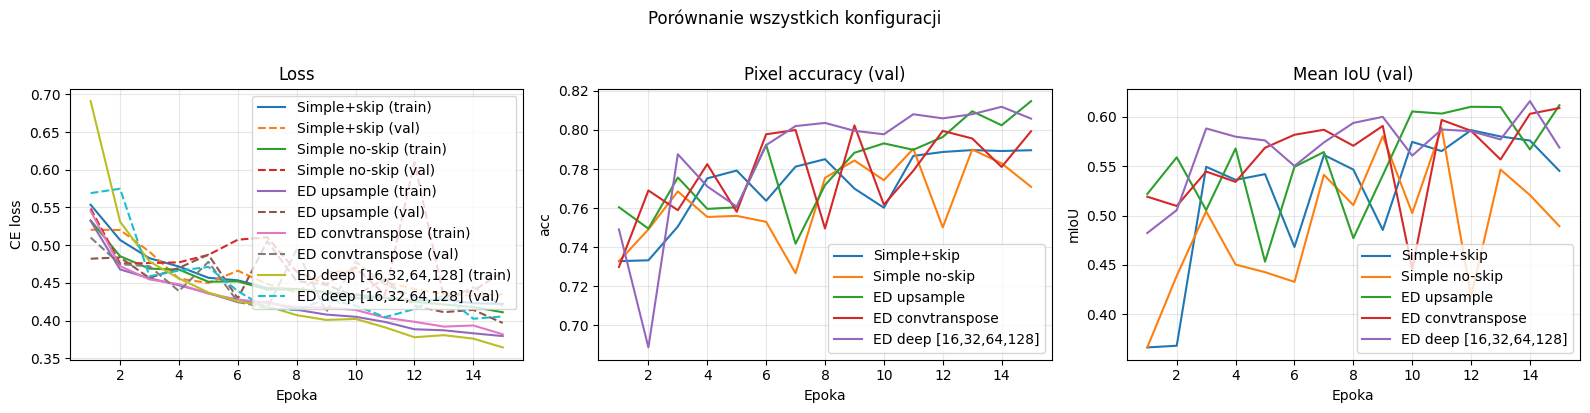

In [18]:
plot_history(
    {
        "Simple+skip":      hist_skip,
        "Simple no-skip":   hist_noskip,
        "ED upsample":      hist_up,
        "ED convtranspose": hist_ct,
        "ED deep [16,32,64,128]": hist_deep,
    },
    title="Porównanie wszystkich konfiguracji",
)


In [19]:
# Tabela końcowa: najlepsze metryki z każdego eksperymentu
import pandas as pd

def best_row(name, h):
    best_idx = int(np.argmax(h["val_iou"]))
    return {
        "model": name,
        "best_epoch": best_idx + 1,
        "val_loss": round(h["val_loss"][best_idx], 4),
        "val_acc": round(h["val_acc"][best_idx], 4),
        "val_mIoU": round(h["val_iou"][best_idx], 4),
        "final_val_mIoU": round(h["val_iou"][-1], 4),
    }

rows = [
    best_row("Simple+skip",                hist_skip),
    best_row("Simple no-skip",             hist_noskip),
    best_row("ED upsample [32,64,128]",    hist_up),
    best_row("ED convtranspose [32,64,128]", hist_ct),
    best_row("ED deep convT [16,32,64,128]", hist_deep),
]
df = pd.DataFrame(rows).set_index("model")
print(df.to_string())


                              best_epoch  val_loss  val_acc  val_mIoU  final_val_mIoU
model                                                                                
Simple+skip                           12    0.4418   0.7887    0.5865          0.5452
Simple no-skip                        11    0.4341   0.7904    0.5888          0.4893
ED upsample [32,64,128]               15    0.3968   0.8148    0.6118          0.6118
ED convtranspose [32,64,128]          15    0.4192   0.7994    0.6089          0.6089
ED deep convT [16,32,64,128]          14    0.4024   0.8119    0.6159          0.5689


### Wizualizacja predykcji wszystkich modeli na tych samych próbkach

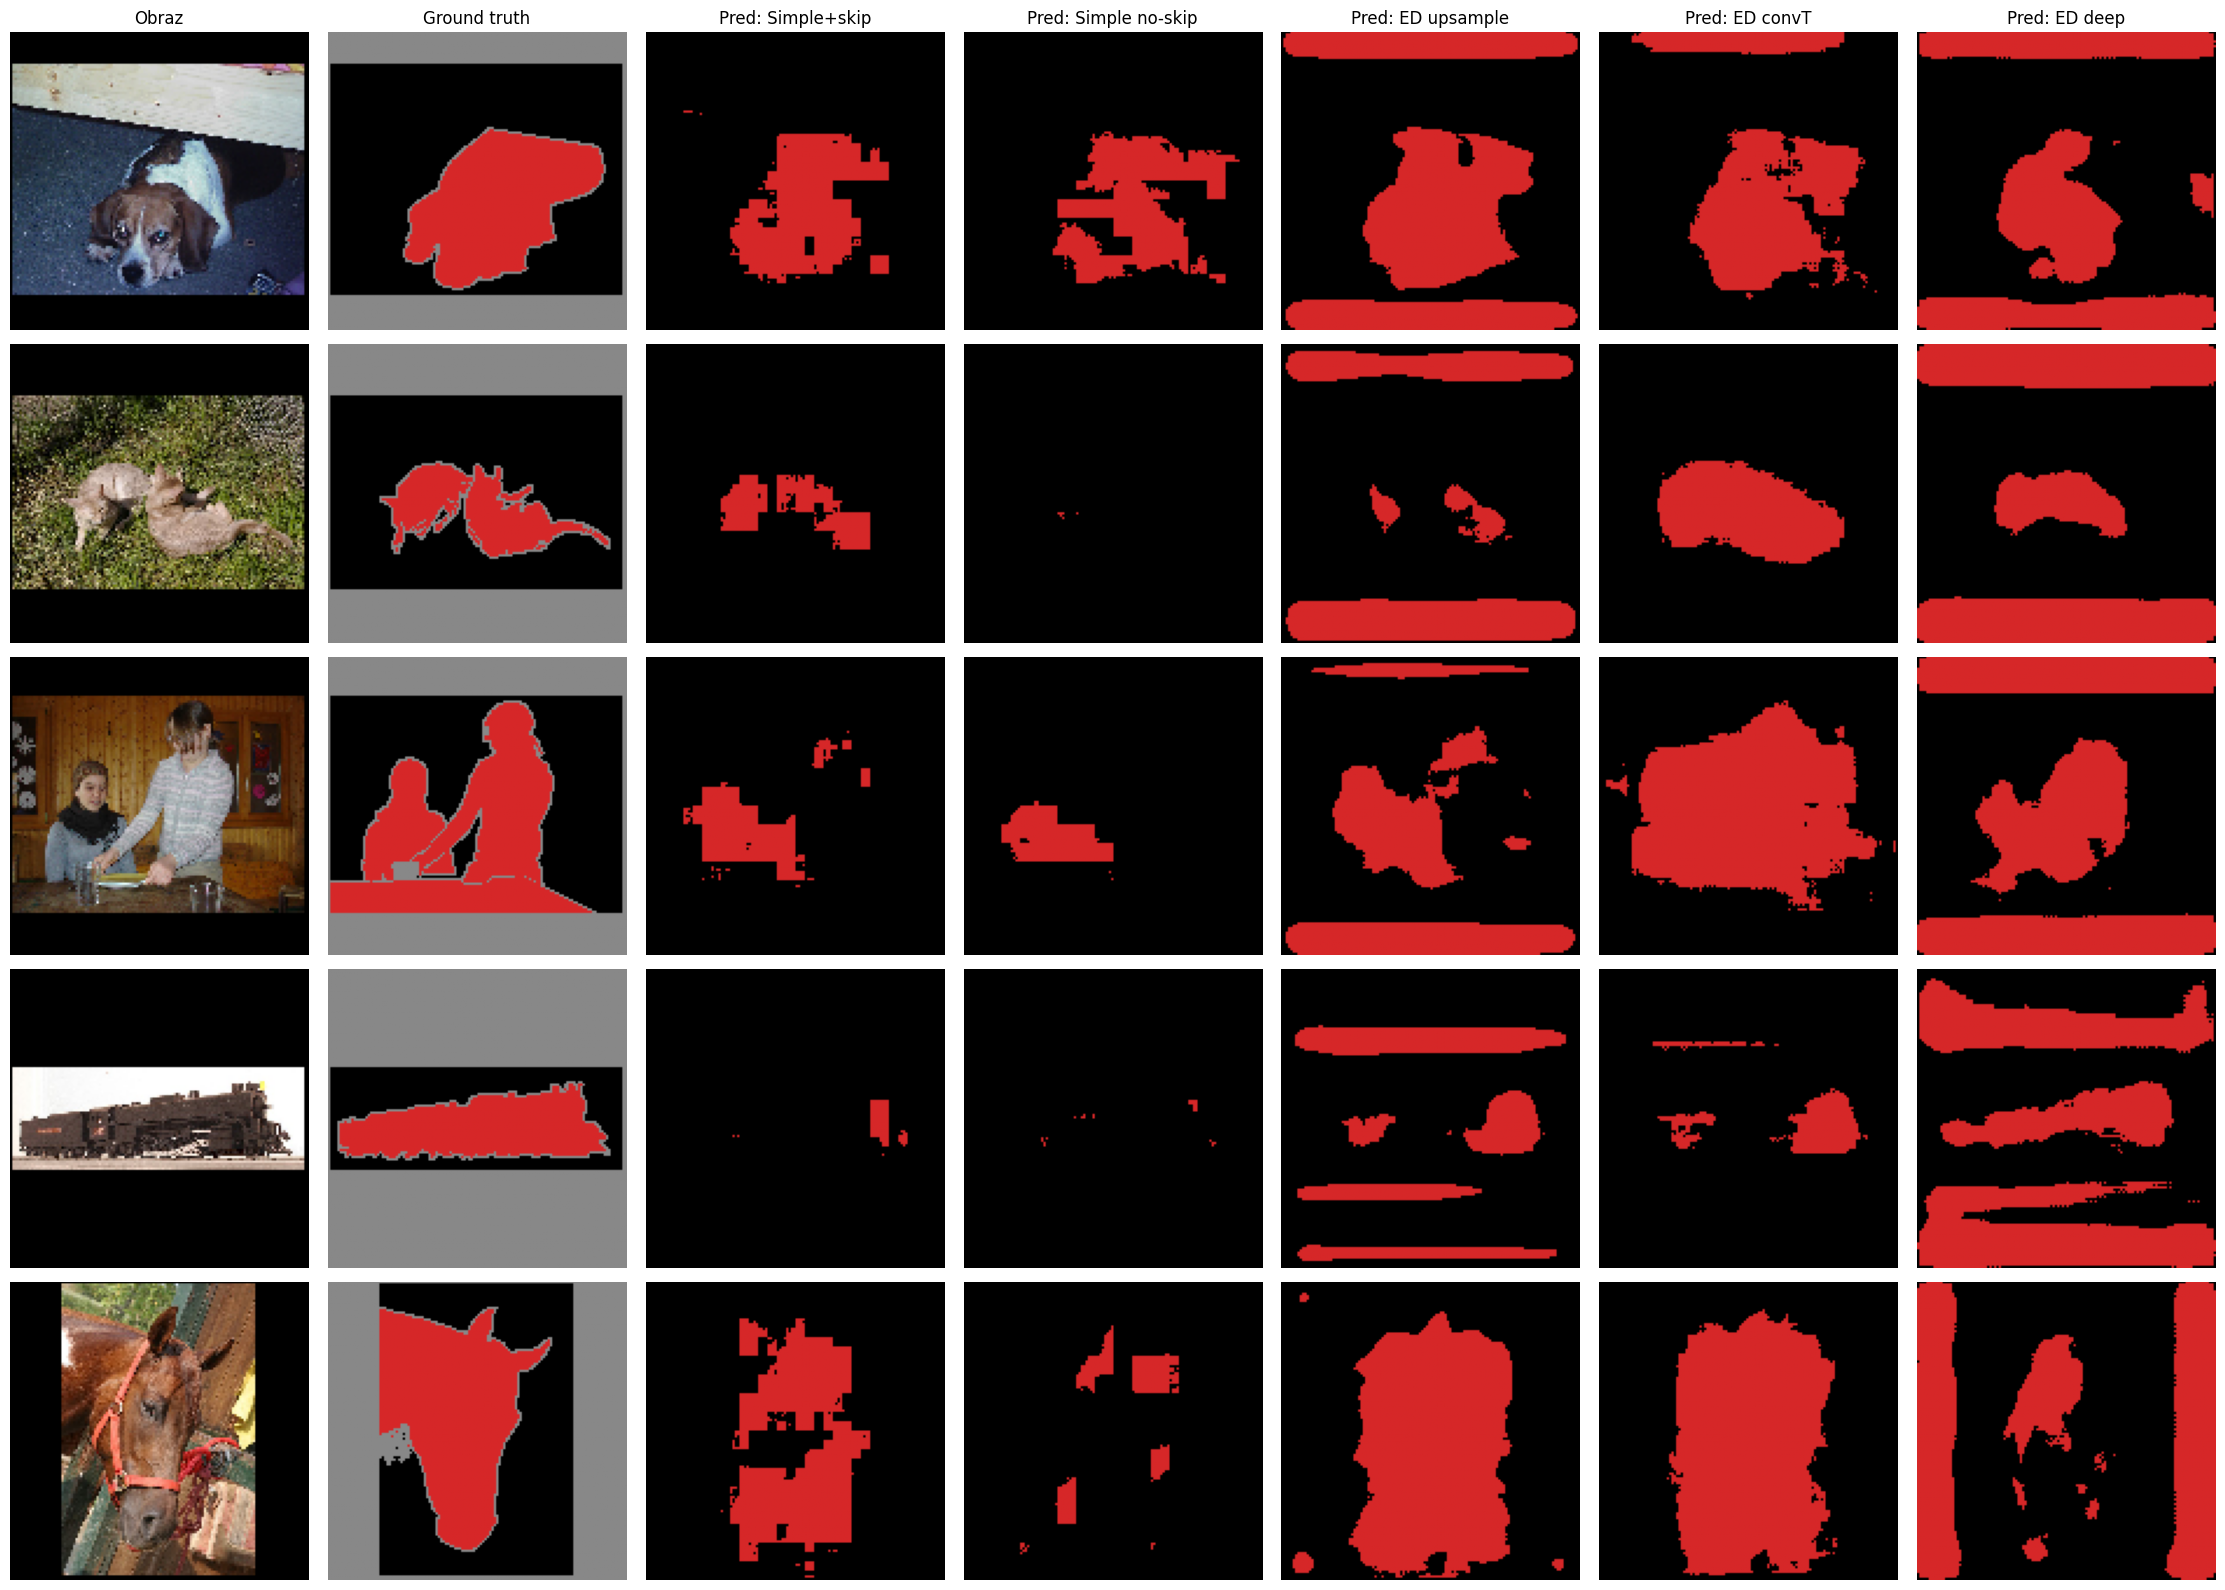

In [20]:
show_predictions(
    {
        "Simple+skip":   model_skip,
        "Simple no-skip": model_noskip,
        "ED upsample":   model_up,
        "ED convT":      model_ct,
        "ED deep":       model_deep,
    },
    test_data,
    n=5,
)


## Wnioski

**Skip-connections działają.** Porównanie eksperymentów 1 i 2 pokazuje, że dodanie połączeń skrótowych poprawia zarówno mIoU, jak i jakość wizualną predykcji - kontury obiektów są ostrzejsze, bo dekoder dostaje informację o geometrii bezpośrednio z enkodera, bez konieczności rekonstrukcji jej z bottlenecku.

**ConvTranspose vs Upsample.** ConvTranspose2d ma uczące się parametry, więc teoretycznie ma większą pojemność. W praktyce na małym, trudnym zbiorze (VOC binarny, ograniczona liczba epok) różnice bywają niewielkie, a Upsample + 1x1 conv jest tańszy obliczeniowo. Wybór zależy od budżetu i danych.

**Głębokość vs jakość.** Dodanie kolejnego poziomu (eksperyment 5) zwiększa pole recepcyjne i pojemność, ale przy ograniczonej liczbie epok i niewielkim zbiorze treningowym poprawa nie jest dramatyczna - większe modele wymagają więcej treningu i danych, by się opłacić.

**Typowe problemy widoczne na predykcjach.** Modele dobrze radzą sobie z dużymi jednolitymi obiektami, gorzej z cienkimi strukturami i obiektami częściowo zasłoniętymi. To naturalne dla architektury bez explicit attention i dla tak prostego setupu z dużym downsamplingiem na wstępie (resize //4).

**Co można poprawić.**

- więcej epok i scheduler learning rate
- mocniejsza augmentacja (random crop, color jitter, small rotations)
- conv blocks 2x conv zamiast 1x (oryginalna architektura U-Net)
- Dice loss albo Focal loss zamiast czystej cross-entropy - pomagają przy niezbalansowaniu
- powrót do oryginalnej rozdzielczości (bez resize //4) jeśli pozwala GPU